# Mass-spring-damper benchmark: adaptive delayed-acceptance MCMC vs. baselines

This notebook is a guided walkthrough of the mass-spring-damper inverse problem used
to benchmark four inference strategies. It is meant to be read top to bottom by
someone unfamiliar with the code, and each figure-producing cell can be edited
in place to change styling, subsets of methods shown, etc.

**The physical problem.** A mass-spring-damper released from rest, `m*x'' + c*x' +
k*x = 0`, `x(0)=x0`, `x'(0)=0`. Mass `m` is fixed/known; the unknowns are stiffness
`k` and damping `c` (see `msd.py` for why mass is fixed: with all three free, only
the natural frequency and damping ratio are identifiable from a single trajectory,
leaving a near-flat ridge in parameter space).

**The four methods being compared** (implemented in `msd_methods.py`):

1. **HF-only Metropolis-Hastings** -- ground-truth reference and the "standard
   single-stage MCMC" baseline. Every step calls the expensive high-fidelity (HF)
   forward model.
2. **Pretrained surrogate + frozen MH** -- a POD-GP surrogate trained *offline only*
   (greedy max-variance active learning, stopping once its own predictive
   uncertainty is below a target), then frozen and used as if it were exact. Matches
   the "Pretrained Model" arm in Riccius et al. (2025).
3. **Riccius-style online active learning** -- the surrogate is substituted directly
   for the likelihood and refined online via an uncertainty threshold, but with *no*
   delayed-acceptance correction step. Matches Algorithm 1 in Riccius et al. (2025),
   "Integration of Active Learning and MCMC Sampling for Efficient Bayesian
   Calibration of Mechanical Properties".
4. **Ours: adaptive delayed-acceptance MCMC with a freeze-to-production stage** --
   the surrogate is refined online during an adaptive phase, guided by the MCMC
   path; once its accuracy stabilizes, it is frozen and a standard delayed-acceptance
   (DA) chain generates the production samples, which carry the DA stationarity
   guarantee (unlike methods 2 and 3).

Methods 2-4 share the same POD-GP surrogate class and the same adaptive
random-walk Metropolis proposal; only the *learning/correction strategy* differs,
so differences between them isolate that strategy's effect rather than surrogate
choice or proposal tuning.

**Everything below (sections 3-9) is repeated for each offline-design size in
`N_INIT_SETTINGS` (10, 20, 40)**, so the whole comparison -- including a 5-chain
R-hat/ESS convergence check -- is shown at every design size, not just one.

In [ ]:
from __future__ import annotations

import json

import matplotlib.pyplot as plt
import numpy as np
from msd_methods import (
    BURN_IN,
    GAMMA_THRESHOLD,
    KERNEL,
    MAX_ADAPT_COARSE_EVALS,
    N_COARSE_EVALS,
    N_INIT_SETTINGS,
    N_REF_ITERATIONS,
    PARAM_NAMES,
    POD_RANK,
    REF_BURN_IN,
    RESULTS_DIR,
    build_initial_surrogate,
    build_problem,
    effective_burn_in,
    ours_coarse_eval_units,
    ours_cumulative_coarse_evals,
    ours_full_resolution_trace,
    ours_multichain_trace,
    print_convergence_driven_table,
    print_convergence_table,
    run_convergence_check,
    run_convergence_driven_comparison,
    run_hf_only,
    run_online_active,
    run_ours,
    run_pretrained,
    summarize,
)

from gp_active_mcmc.diagnostics import plot_prediction_at_theta
from gp_active_mcmc.utils.rng import set_seed

RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)


def save_fig(fig, name: str, n_init: int) -> None:
    """Save a figure to RESULTS_DIR/figures/{name}_n_init_{n_init}.png, at the
    savefig.dpi set in the rcParams below, and print the path (relative to
    examples/toy_problem/) so it's easy to find without leaving the notebook."""
    path = FIGURES_DIR / f"{name}_n_init_{n_init}.png"
    fig.savefig(path, bbox_inches="tight")
    print(f"  saved {path.relative_to(RESULTS_DIR.parent)}")


N_CHAINS = 5  # used for every convergence check below
N_COARSE_EVALS_LONG = 1000  # long horizon for the convergence check specifically, so R-hat has room to resolve

# Convergence-driven comparison (section 5b): chunk size and safety cap, both in
# coarse-evaluation units (uniform currency across all four methods -- see
# run_until_rhat_converged's docstring in msd_methods.py). rhat_threshold=1.01 and
# min_ess=400 together (not R-hat alone) are what find_burn_in_via_rhat requires
# before declaring a method converged -- see its docstring for why R-hat alone can
# pass "by luck" on a too-small sample (this bit `ours` at low n_init, where its
# frozen production rows are each expensive relative to chunk_size).
CONVERGENCE_DRIVEN_CHUNK_SIZE = 500
CONVERGENCE_DRIVEN_MAX_TOTAL_COARSE_EVALS = 10_000
CONVERGENCE_DRIVEN_RHAT_THRESHOLD = 1.01
CONVERGENCE_DRIVEN_MIN_ESS = 400

# Paper-style figure defaults: applied once here, inherited by every plot below.
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.axisbelow": True,
})

# "hf_only_matched" (section 4's single quick-look chain) and "hf_only" (the method-name
# key used by run_convergence_check/run_convergence_driven_comparison's multi-chain
# dicts) are kept as separate keys since they come from different call sites, but map
# to the same styling.
METHOD_COLORS = {
    "hf_only_matched": "0.35",
    "hf_only": "0.35",
    "pretrained": "tab:red",
    "online_active": "tab:orange",
    "ours": "tab:blue",
}
METHOD_MARKERS = {"pretrained": "s", "online_active": "^", "ours": "o"}
METHOD_LABELS = {
    "hf_only_matched": "MH with HF",
    "hf_only": "MH with HF",
    "pretrained": "Pretrained (offline)",
    "online_active": "Riccius-style online",
    "ours": "Ours (adaptive DA + freeze)",
}
METHOD_ORDER = ("pretrained", "online_active", "ours")
TRACE_METHOD_ORDER = ("hf_only_matched", "pretrained", "online_active", "ours")
TRACE_METHOD_ORDER_MULTICHAIN = ("hf_only", "pretrained", "online_active", "ours")

# Shared colors for the LF-step/HF-call coloring used by the trace plots.
LF_COLOR = "tab:blue"
HF_COLOR = "tab:red"


## 1. Problem setup

A single problem instance: fixed `theta_true` (drawn from the prior), a noisy
synthetic observation. Edit `PROBLEM_SEED` below and re-run the notebook to explore
a different instance. This does not depend on `n_init`, so it's computed once.

theta_true: {'k': 58.21770123928726, 'c': 2.809360141291611}


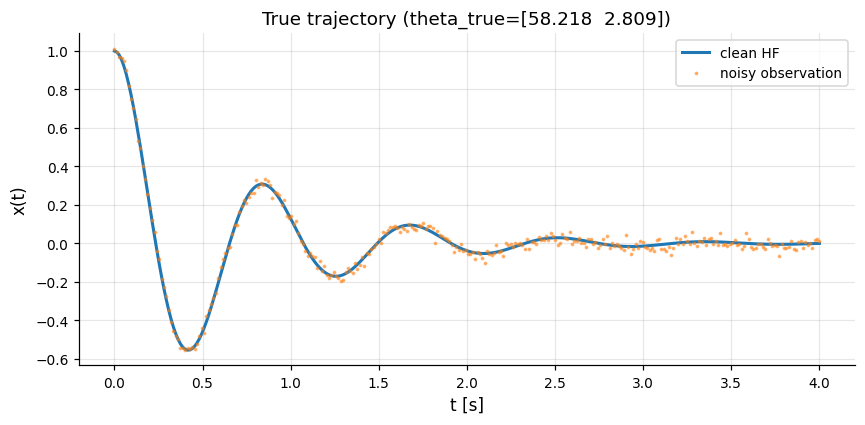

In [2]:
PROBLEM_SEED = 0
problem = build_problem(problem_seed=PROBLEM_SEED, sigma_obs=0.02)
print("theta_true:", dict(zip(PARAM_NAMES, problem.theta_true.tolist(), strict=True)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(problem.t, problem.hf_forward(problem.theta_true), lw=2, label="clean HF")
ax.plot(problem.t, problem.y_obs, ".", ms=3, alpha=0.5, label="noisy observation")
ax.set_xlabel("t [s]")
ax.set_ylabel("x(t)")
ax.legend()
ax.set_title(f"True trajectory (theta_true={np.round(problem.theta_true, 3)})")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "true_trajectory.png", bbox_inches="tight")


## 2. HF-only reference chains

Also n_init-independent: a long, well-converged chain used as ground truth for
accuracy comparisons, plus a budget-matched (N=N_COARSE_EVALS) chain used both as the
"standard single-stage MCMC" baseline and as the trace-plot comparison row.

In [3]:
chain_ref = run_hf_only(problem, iterations=N_REF_ITERATIONS, seed=10_000)
ref_mean = chain_ref.burn_in(REF_BURN_IN).samples.mean(axis=0)
print("hf_only_reference:", summarize(chain_ref, problem, burn_in=REF_BURN_IN))

chain_hf_matched = run_hf_only(problem, iterations=N_COARSE_EVALS, seed=11_000)
print("hf_only_matched:", summarize(chain_hf_matched, problem, burn_in=BURN_IN, reference_mean=ref_mean))


Sampling chain 1/1


Running chain, α = 0.15: 100%|██████████| 3000/3000 [00:11<00:00, 263.03it/s]


hf_only_reference: {'n_steps': 3001, 'posterior_mean': [58.36164489185279, 2.8068051123437354], 'posterior_std': [0.173348053526813, 0.02194715260074239], 'rmse_to_truth': 0.18318257151028836, 'n_offline_hf': 0, 'n_hf_calls_online': 3001, 'n_hf_calls': 3001, 'hf_call_fraction': 1.0}
Sampling chain 1/1


Running chain, α = 0.24: 100%|██████████| 1000/1000 [00:03<00:00, 290.32it/s]


hf_only_matched: {'n_steps': 1001, 'posterior_mean': [58.330321859927, 2.7988431997391903], 'posterior_std': [0.2372912485151039, 0.031060666544757445], 'rmse_to_truth': 0.20576306958636706, 'n_offline_hf': 0, 'n_hf_calls_online': 1001, 'n_hf_calls': 1001, 'hf_call_fraction': 1.0, 'mean_abs_dev_from_reference': [0.031323031925794, 0.007961912604545152]}


## 3. Helper functions

Defined once, then invoked for each `n_init` in `N_INIT_SETTINGS` in the loop below.

In [4]:
def run_all_methods(problem, *, n_init: int, pod_rank: int, seed_offset: int):
    """Build the initial surrogate and run all four surrogate-based methods."""
    seed_surrogate, seed_X, seed_Y = build_initial_surrogate(
        problem, set_seed(1_000 + seed_offset), n_init=n_init, pod_rank=pod_rank, kernel=KERNEL
    )

    chain_ours, meta_ours, surrogate_ours = run_ours(
        problem,
        surrogate=seed_surrogate,
        gamma_threshold=GAMMA_THRESHOLD,
        n_coarse_evals=N_COARSE_EVALS,
        max_adapt_coarse_evals=MAX_ADAPT_COARSE_EVALS,
        seed=12_000 + seed_offset,
    )
    chain_pretrained, n_hf_pretrained, surrogate_pretrained = run_pretrained(
        problem,
        seed_X=seed_X,
        seed_Y=seed_Y,
        gamma_threshold=GAMMA_THRESHOLD,
        pod_rank=pod_rank,
        kernel=KERNEL,
        iterations=N_COARSE_EVALS,
        seed=13_000 + seed_offset,
    )
    chain_online, surrogate_online = run_online_active(
        problem,
        surrogate=seed_surrogate,
        gamma_threshold=GAMMA_THRESHOLD,
        iterations=N_COARSE_EVALS,
        seed=14_000 + seed_offset,
    )

    return {
        "seed_surrogate": seed_surrogate,
        "seed_X": seed_X,
        "seed_Y": seed_Y,
        "chains": {"pretrained": chain_pretrained, "online_active": chain_online, "ours": chain_ours},
        "surrogates_after": {
            "pretrained": surrogate_pretrained, "online_active": surrogate_online, "ours": surrogate_ours
        },
        "n_hf_pretrained": n_hf_pretrained,
        "meta_ours": meta_ours,
    }


def print_summary_table(problem, n_init, res):
    # `ours` burn-in must discard the whole (non-stationary) adaptive phase, not the
    # shared BURN_IN=100 -- see effective_burn_in()'s docstring for why. `ours` also
    # needs `n_coarse_eval_units` for its HF-call-fraction denominator, since its chain
    # rows aren't one-coarse-eval-per-row throughout (see ours_coarse_eval_units()).
    summary = {
        "ours": summarize(
            res["chains"]["ours"], problem, burn_in=effective_burn_in("ours", meta_ours=res["meta_ours"]),
            reference_mean=ref_mean, n_offline_hf=n_init,
            n_coarse_eval_units=ours_coarse_eval_units(res["meta_ours"]),
        ),
        "pretrained": summarize(
            res["chains"]["pretrained"], problem, burn_in=BURN_IN, reference_mean=ref_mean,
            n_offline_hf=res["n_hf_pretrained"],
        ),
        "online_active": summarize(
            res["chains"]["online_active"], problem, burn_in=BURN_IN, reference_mean=ref_mean, n_offline_hf=n_init
        ),
    }
    for name, s in summary.items():
        print(
            f"{name:<16} hf_total={s['n_hf_calls']:>5} hf_frac={s['hf_call_fraction']:.3f}  "
            f"rmse={s['rmse_to_truth']:.4f}  mean={np.round(s['posterior_mean'], 3)}"
        )
    (RESULTS_DIR / f"notebook_summary_n_init_{n_init}.json").write_text(json.dumps(summary, indent=2))
    return summary


def plot_posterior_comparison(problem, n_init, chain_ref, chains, meta_ours):
    # Same fix as print_summary_table: `ours` must use its own adaptive-phase length as
    # burn-in, not the shared BURN_IN, or the scatter mixes in non-stationary samples.
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ref_post = chain_ref.burn_in(REF_BURN_IN).samples
    ax.hexbin(ref_post[:, 0], ref_post[:, 1], gridsize=40, cmap="Greys", mincnt=1, alpha=0.55, zorder=1)
    for name in METHOD_ORDER:
        b = effective_burn_in(name, meta_ours=meta_ours) if name == "ours" else BURN_IN
        post = chains[name].burn_in(b).samples
        ax.scatter(
            post[:, 0], post[:, 1], s=26, alpha=0.55, facecolors="none", edgecolors=METHOD_COLORS[name],
            marker=METHOD_MARKERS[name], linewidths=1.0, label=METHOD_LABELS[name], zorder=3,
        )
    ax.scatter(*problem.theta_true, s=180, c="k", marker="*", zorder=5, label=r"$\theta_{\mathrm{true}}$")
    ax.set_xlabel(PARAM_NAMES[0])
    ax.set_ylabel(PARAM_NAMES[1])
    ax.set_title(f"Posterior comparison (n_init={n_init})")
    ax.legend(fontsize=9)
    fig.tight_layout()
    return fig


def combined_hf_fraction_curve(
    n_offline: int, used_hf_online: np.ndarray, *, x: np.ndarray | None = None
) -> tuple[np.ndarray, np.ndarray]:
    """Cumulative HF fraction including upfront offline cost (paid "before iteration 1").

    `x` overrides the default x-axis (row index) with an explicit per-row cumulative
    coarse-evaluation count -- needed for `ours` (via `ours_cumulative_coarse_evals`),
    whose rows are one coarse evaluation each only during the adaptive phase; during
    the frozen production phase each row is a whole DA block of several coarse
    evaluations, so row index alone would compress that phase into a misleadingly
    short, steep stretch of the plot. Defaults to `np.arange(1, n+1)`, correct for the
    other three methods (whose rows already are one coarse evaluation each).
    """
    online = used_hf_online.astype(float)
    it = np.arange(1, online.size + 1, dtype=float) if x is None else np.asarray(x, dtype=float)
    cum_hf = n_offline + np.cumsum(online)
    return it, cum_hf / (n_offline + it)


def plot_hf_fraction(n_init, chains, n_hf_pretrained, meta_ours):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    offline_costs = {"pretrained": n_hf_pretrained, "online_active": n_init, "ours": n_init}
    for name in METHOD_ORDER:
        chain = chains[name]
        used_hf = chain.extras.used_hf if chain.extras.used_hf is not None else np.zeros(chain.n_steps, dtype=bool)
        x = ours_cumulative_coarse_evals(meta_ours) if name == "ours" else None
        it, frac = combined_hf_fraction_curve(offline_costs[name], used_hf, x=x)
        ax.plot(it, frac, color=METHOD_COLORS[name], lw=1.8, label=f"{METHOD_LABELS[name]} (offline={offline_costs[name]})")
    ax.set_xlabel("Coarse-evaluation iteration")
    ax.set_ylabel("Cumulative HF fraction\n(offline cost included)")
    ax.set_title(f"HF usage (n_init={n_init})")
    ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=9)
    fig.tight_layout()
    return fig


def _method_full_resolution_trace(name, chain, meta_ours):
    """(x, samples, used_hf) at full temporal resolution for one method's trace.

    For every method except `ours`, `chain` already *is* full resolution (one row per
    coarse evaluation, with its own genuine `used_hf` flag): `hf_only_matched` is
    trivially all-True, `pretrained` is trivially all-False (frozen, never calls HF
    online), `online_active` is a genuine mix. Only `ours` needs reconstruction, via
    `ours_full_resolution_trace`, because its posterior-inference chain
    (`chain_fine_0`) skips the intra-block low-fidelity steps during production.
    """
    if name == "ours":
        return ours_full_resolution_trace(chain, meta_ours)
    x = np.arange(1, chain.n_steps + 1, dtype=float)
    used_hf = chain.extras.used_hf if chain.extras.used_hf is not None else np.zeros(chain.n_steps, dtype=bool)
    return x, chain.samples, used_hf


def make_hf_colored_trace_fig(problem, n_init, trace_chains, meta_ours, burn_ins: dict[str, int], mode: str, title_suffix: str):
    """Trace plot at full temporal resolution, colored by whether each point required
    an HF evaluation (blue = cheap LF/surrogate step, red = expensive HF call).

    Without this, `ours`'s trace (built from `chain_fine_0`, one point per DA block)
    looks like a sparse sequence of big jumps and makes the other methods -- which
    plot *every* coarse step -- look artificially better-mixed by comparison, even
    though `ours` is doing much more (cheap) exploration between each (expensive)
    HF-corrected sample than its trace alone would suggest.

    mode="full": every sample (x in coarse-evaluation-iteration units), with a
    vertical line at each row's own burn-in.
    mode="post_burn_in": only samples after each row's own burn-in (per-method, not a
    single shared offset -- `ours` uses its adaptive-phase length, others use BURN_IN).
    """
    fig, axes = plt.subplots(len(TRACE_METHOD_ORDER), 2, figsize=(11, 2.6 * len(TRACE_METHOD_ORDER)), sharex=False)
    for r, name in enumerate(TRACE_METHOD_ORDER):
        x, samples, used_hf = _method_full_resolution_trace(name, trace_chains[name], meta_ours)
        b = burn_ins[name]
        if mode == "post_burn_in":
            mask = x > b
            x, samples, used_hf = x[mask], samples[mask], used_hf[mask]
        for p in range(2):
            ax = axes[r, p]
            ax.plot(x, samples[:, p], color="0.8", lw=0.5, zorder=1)
            ax.scatter(
                x[~used_hf], samples[~used_hf, p], s=4, color=LF_COLOR, alpha=0.5, zorder=2, label="LF step"
            )
            ax.scatter(
                x[used_hf], samples[used_hf, p], s=16, color=HF_COLOR, alpha=0.9, zorder=3, label="HF call"
            )
            ax.axhline(problem.theta_true[p], color="k", ls="--", lw=1)
            if mode == "full":
                ax.axvline(b, color="tab:green", ls=":", lw=1.5)
            if r == 0:
                ax.set_title(PARAM_NAMES[p])
            if p == 0:
                ax.set_ylabel(METHOD_LABELS.get(name, name), fontsize=9)
            if r == 0 and p == 1:
                ax.legend(fontsize=7, loc="upper right", markerscale=2)
    for p in range(2):
        axes[-1, p].set_xlabel("Coarse-evaluation iteration")
    fig.suptitle(f"Trace plots (LF/HF colored){title_suffix} (n_init={n_init})")
    fig.tight_layout()
    return fig


def plot_surrogate_before_after(problem, n_init, seed_surrogate, surrogates_after):
    fig, axes = plt.subplots(1, len(METHOD_ORDER), figsize=(6 * len(METHOD_ORDER), 4), sharey=True)
    t = problem.t
    y_true = problem.hf_forward(problem.theta_true)
    for a, name in enumerate(METHOD_ORDER):
        ax = axes[a]
        ax.plot(t, problem.y_obs, ".", ms=2, alpha=0.3, color="0.5", label="observations")
        ax.plot(t, y_true, color="k", lw=1.5, label="true profile")

        mean_before, var_before = seed_surrogate.predict(problem.theta_true)
        ax.plot(t, mean_before, color="tab:gray", lw=1.5, label="surrogate (before)")
        ax.fill_between(
            t, mean_before - 2 * np.sqrt(var_before), mean_before + 2 * np.sqrt(var_before),
            color="tab:gray", alpha=0.2,
        )

        mean_after, var_after = surrogates_after[name].predict(problem.theta_true)
        ax.plot(t, mean_after, color=METHOD_COLORS[name], lw=1.5, label="surrogate (after)")
        ax.fill_between(
            t, mean_after - 2 * np.sqrt(var_after), mean_after + 2 * np.sqrt(var_after),
            color=METHOD_COLORS[name], alpha=0.25,
        )

        ax.set_title(METHOD_LABELS[name])
        ax.set_xlabel("t")
        if a == 0:
            ax.set_ylabel("x(t)")
            ax.legend(fontsize=8)
    fig.suptitle(f"Surrogate prediction at theta_true, before vs. after learning (n_init={n_init})")
    fig.tight_layout()
    return fig


def plot_pooled_posterior_comparison(problem, n_init, chain_ref, conv_results, chains_by_method):
    """Posterior comparison using the R-hat-validated burn-in and samples pooled across
    all replicate chains -- the "real" version, vs. section 4's single-chain preview
    (which uses a heuristic burn-in and one chain per method)."""
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ref_post = chain_ref.burn_in(REF_BURN_IN).samples
    ax.hexbin(ref_post[:, 0], ref_post[:, 1], gridsize=40, cmap="Greys", mincnt=1, alpha=0.55, zorder=1)
    for name in METHOD_ORDER:
        b = conv_results[name]["burn_in"] or 0
        chains = chains_by_method[name]
        pooled = np.concatenate([c.burn_in(b).samples for c in chains], axis=0)
        w2 = conv_results[name]["pooled"].get("wasserstein2_to_reference")
        label = f"{METHOD_LABELS[name]} (burn_in={b}, {len(chains)} chains"
        label += f", W2={w2:.3f})" if w2 is not None else ")"
        ax.scatter(
            pooled[:, 0], pooled[:, 1], s=14, alpha=0.35, facecolors="none", edgecolors=METHOD_COLORS[name],
            marker=METHOD_MARKERS[name], linewidths=0.8, label=label, zorder=3,
        )
    ax.scatter(*problem.theta_true, s=180, c="k", marker="*", zorder=5, label=r"$\theta_{\mathrm{true}}$")
    ax.set_xlabel(PARAM_NAMES[0])
    ax.set_ylabel(PARAM_NAMES[1])
    ax.set_title(f"Pooled posterior, R-hat-validated burn-in (n_init={n_init})")
    ax.legend(fontsize=8)
    fig.tight_layout()
    return fig


# ---------------------------------------------------------------------------
# Multi-chain (N_CHAINS-replicate) versions of section 4's per-figure-type plots.
# ---------------------------------------------------------------------------
#
# Section 4's plots (posterior comparison, HF fraction, trace, surrogate before/after)
# each use a single quick-look chain per method. `plot_pooled_posterior_comparison`
# above already has a multi-chain analog for the posterior-comparison plot; the three
# functions below extend the same idea to the other three plot types, so every figure
# type is available at both single-chain (section 4) and N_CHAINS-replicate (section 5
# / 5b) resolution. All three take a common `offline_costs_by_method` /
# `surrogates_by_method` shape: `results[name]["pooled"]["n_offline_hf"]` is *always* a
# per-chain list (that's how `pooled_summarize` reports it, whether the underlying
# `n_offline_hf` argument was a scalar or already a list), so
# `{name: r["pooled"]["n_offline_hf"] for name, r in results.items()}` works
# identically for both `run_convergence_check` and `run_convergence_driven_comparison`.


def prepare_multichain_traces_section5(chains_by_method, ours_metas):
    """Per-chain (x, samples, used_hf) triples for every method, from
    `run_convergence_check`'s output. Full LF resolution for `ours`, via
    `ours_full_resolution_trace`, since `run_convergence_check` calls `run_ours`
    directly per replicate (so each replicate's full `run_ours`-style metadata,
    including its `production_diagnostic_chain`, is available)."""
    traces = {}
    for name in ("hf_only", "pretrained", "online_active"):
        traces[name] = [
            (
                np.arange(1, c.n_steps + 1, dtype=float),
                c.samples,
                c.extras.used_hf if c.extras.used_hf is not None else np.zeros(c.n_steps, dtype=bool),
            )
            for c in chains_by_method[name]
        ]
    traces["ours"] = [
        ours_full_resolution_trace(c, m) for c, m in zip(chains_by_method["ours"], ours_metas, strict=True)
    ]
    return traces


def prepare_multichain_traces_section5b(chains_by_method, results):
    """Per-chain (x, samples, used_hf) triples for every method, from
    `run_convergence_driven_comparison`'s output. `ours` is at DA-block resolution
    during production (see `ours_multichain_trace`'s docstring for why: the chunked
    replicate runs don't request a per-chunk diagnostic chain, unlike `run_ours`), not
    full LF resolution the way section 5's version is."""
    traces = {}
    for name in ("hf_only", "pretrained", "online_active"):
        traces[name] = [
            (
                np.arange(1, c.n_steps + 1, dtype=float),
                c.samples,
                c.extras.used_hf if c.extras.used_hf is not None else np.zeros(c.n_steps, dtype=bool),
            )
            for c in chains_by_method[name]
        ]
    adapt_metas = results["ours"]["adapt_metas"]
    coarse_evals_per_chain = results["ours"]["coarse_evals_per_chain"]
    ours_traces = []
    for adapt_chain, adapt_meta, production_chain, production_cost in zip(
        chains_by_method["ours_adapt"], adapt_metas, chains_by_method["ours"], coarse_evals_per_chain, strict=True
    ):
        # frozen_rate is exactly production_cost / (n genuine new production rows):
        # subsampling_rate is constant throughout production (frozen), and
        # coarse_evals_per_chain already sums iterations*subsampling_rate per round --
        # see _run_chunk's docstring in msd_methods.py.
        frozen_rate = production_cost // (production_chain.n_steps - 1) if production_chain.n_steps > 1 else 1
        ours_traces.append(ours_multichain_trace(adapt_chain, adapt_meta, production_chain, frozen_rate))
    traces["ours"] = ours_traces
    return traces


def plot_hf_fraction_multichain(n_init, traces, offline_costs_by_method, title_suffix=""):
    """Overlay every replicate chain's cumulative HF-fraction curve per method (thin,
    semi-transparent lines) -- shows both the typical cost and how much it varies
    across independent replicates, which a single chain can't show."""
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for name in METHOD_ORDER:
        chain_traces = traces[name]
        offline_costs = offline_costs_by_method[name]
        for i, (x, _samples, used_hf) in enumerate(chain_traces):
            it, frac = combined_hf_fraction_curve(offline_costs[i], used_hf, x=x)
            ax.plot(
                it, frac, color=METHOD_COLORS[name], lw=1.0, alpha=0.45,
                label=f"{METHOD_LABELS[name]} ({len(chain_traces)} chains)" if i == 0 else None,
            )
    ax.set_xlabel("Coarse-evaluation iteration")
    ax.set_ylabel("Cumulative HF fraction\n(offline cost included)")
    ax.set_title(f"HF usage across replicate chains{title_suffix} (n_init={n_init})")
    ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=9)
    fig.tight_layout()
    return fig


def make_hf_colored_trace_fig_multichain(problem, n_init, traces, title_suffix=""):
    """Overlay every replicate chain's LF/HF-colored trace per method/param (faint
    points so `N_CHAINS` overlapping chains stay legible) -- the multi-chain analog of
    `make_hf_colored_trace_fig`, showing the aggregate LF/HF pattern across replicates
    rather than one chain's specific path."""
    fig, axes = plt.subplots(
        len(TRACE_METHOD_ORDER_MULTICHAIN), 2, figsize=(11, 2.6 * len(TRACE_METHOD_ORDER_MULTICHAIN)), sharex=False
    )
    for r, name in enumerate(TRACE_METHOD_ORDER_MULTICHAIN):
        chain_traces = traces[name]
        for p in range(2):
            ax = axes[r, p]
            for i, (x, samples, used_hf) in enumerate(chain_traces):
                ax.plot(x, samples[:, p], color="0.85", lw=0.3, zorder=1)
                ax.scatter(
                    x[~used_hf], samples[~used_hf, p], s=3, color=LF_COLOR, alpha=0.35, zorder=2,
                    label="LF step" if (i == 0 and r == 0 and p == 1) else None,
                )
                ax.scatter(
                    x[used_hf], samples[used_hf, p], s=10, color=HF_COLOR, alpha=0.6, zorder=3,
                    label="HF call" if (i == 0 and r == 0 and p == 1) else None,
                )
            ax.axhline(problem.theta_true[p], color="k", ls="--", lw=1)
            if r == 0:
                ax.set_title(PARAM_NAMES[p])
            if p == 0:
                ax.set_ylabel(f"{METHOD_LABELS.get(name, name)}\n({len(chain_traces)} chains)", fontsize=9)
            if r == 0 and p == 1:
                ax.legend(fontsize=7, loc="upper right", markerscale=2)
    for p in range(2):
        axes[-1, p].set_xlabel("Coarse-evaluation iteration")
    fig.suptitle(f"Trace plots across replicate chains (LF/HF colored){title_suffix} (n_init={n_init})")
    fig.tight_layout()
    return fig


def plot_surrogate_before_after_multichain(problem, n_init, seed_surrogate, surrogates_by_method, title_suffix=""):
    """Overlay every replicate's trained ('after') surrogate prediction at theta_true,
    per method -- shows how consistent the learned surrogate is across independent
    replicate runs (e.g. `pretrained`'s offline design differs every replicate), not
    just a single one."""
    fig, axes = plt.subplots(1, len(METHOD_ORDER), figsize=(6 * len(METHOD_ORDER), 4), sharey=True)
    t = problem.t
    y_true = problem.hf_forward(problem.theta_true)
    mean_before, var_before = seed_surrogate.predict(problem.theta_true)
    for a, name in enumerate(METHOD_ORDER):
        ax = axes[a]
        ax.plot(t, problem.y_obs, ".", ms=2, alpha=0.3, color="0.5", label="observations")
        ax.plot(t, y_true, color="k", lw=1.5, label="true profile")
        ax.plot(t, mean_before, color="tab:gray", lw=1.2, ls=":", label="surrogate (before)")

        surrogates_after = surrogates_by_method[name]
        for i, surrogate in enumerate(surrogates_after):
            mean_after, _var_after = surrogate.predict(problem.theta_true)
            ax.plot(
                t, mean_after, color=METHOD_COLORS[name], lw=1.0, alpha=0.5,
                label="surrogate (after)" if i == 0 else None,
            )

        ax.set_title(f"{METHOD_LABELS[name]} ({len(surrogates_after)} replicates)")
        ax.set_xlabel("t")
        if a == 0:
            ax.set_ylabel("x(t)")
            ax.legend(fontsize=8)
    fig.suptitle(f"Surrogate prediction at theta_true across replicates{title_suffix} (n_init={n_init})")
    fig.tight_layout()
    return fig


## 4. Run everything for each `n_init`

For each offline-design size: run all four methods, print the summary table, and show
the posterior comparison / HF-usage / trace / surrogate-before-after figures. The slow
multi-chain R-hat/ESS convergence check is deferred to its own section below, so these
(comparatively fast) figures don't have to wait on it.



==================== n_init = 10 ====================


 /Users/filippozacchei/COde/MFDA_ActiveLearning/.venv/lib/python3.10/site-packages/tinyDA/sampler.py:114: UserWarning: subsampling_rate has been deprecated in favour of subchain_length.


Sampling chain 1/1


Running chain, α_c = 1.000, α_f = 1.00:   0%|          | 0/10 [00:00<?, ?it/s] /Users/filippozacchei/COde/MFDA_ActiveLearning/.venv/lib/python3.10/site-packages/tinyDA/proposal.py:258: RuntimeWarning:overflow encountered in exp
 /Users/filippozacchei/COde/MFDA_ActiveLearning/.venv/lib/python3.10/site-packages/tinyDA/proposal.py:258: RuntimeWarning:overflow encountered in exp
 /Users/filippozacchei/COde/MFDA_ActiveLearning/.venv/lib/python3.10/site-packages/tinyDA/proposal.py:258: RuntimeWarning:overflow encountered in exp
Running chain, α_c = 0.667, α_f = 0.50:  10%|█         | 1/10 [00:01<00:10,  1.22s/it] /Users/filippozacchei/COde/MFDA_ActiveLearning/.venv/lib/python3.10/site-packages/tinyDA/proposal.py:258: RuntimeWarning:overflow encountered in exp
 /Users/filippozacchei/COde/MFDA_ActiveLearning/.venv/lib/python3.10/site-packages/tinyDA/proposal.py:258: RuntimeWarning:overflow encountered in exp
 /Users/filippozacchei/COde/MFDA_ActiveLearning/.venv/lib/python3.10/site-packages/tin

Sampling chain 1/1


...

Sampling chain 1/1


Running chain, α = 0.39: 100%|██████████| 1000/1000 [00:11<00:00, 83.36it/s]
 /Users/filippozacchei/COde/MFDA_ActiveLearning/.venv/lib/python3.10/site-packages/tinyDA/sampler.py:114: UserWarning: subsampling_rate has been deprecated in favour of subchain_length.


Sampling chain 1/1


Running chain, α = 0.18: 100%|██████████| 1000/1000 [00:12<00:00, 79.43it/s]



--- summary (n_init=40) ---
ours             hf_total=   67 hf_frac=0.067  rmse=0.1154  mean=[58.278  2.807]
pretrained       hf_total=   65 hf_frac=0.061  rmse=0.1297  mean=[58.26   2.812]
online_active    hf_total=   40 hf_frac=0.038  rmse=0.1651  mean=[58.297  2.808]
  saved results/figures/posterior_comparison_n_init_40.png
  saved results/figures/hf_fraction_n_init_40.png
  saved results/figures/trace_full_n_init_40.png
  saved results/figures/trace_post_burn_in_n_init_40.png
  saved results/figures/surrogate_before_after_n_init_40.png


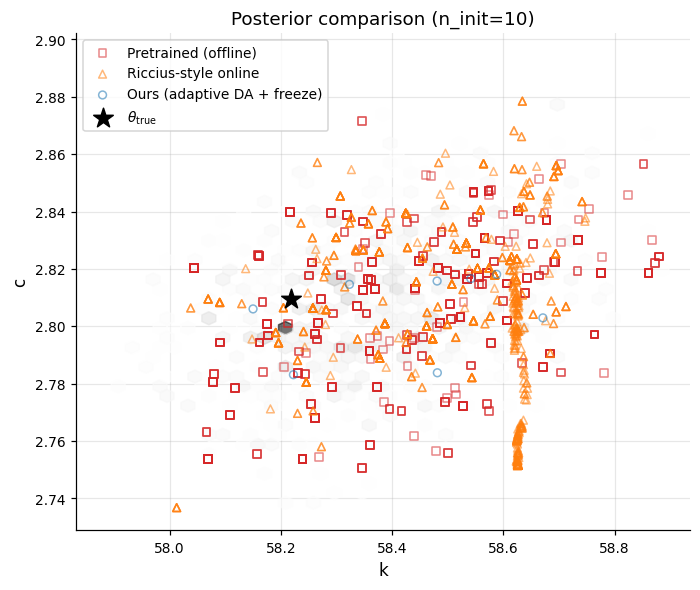

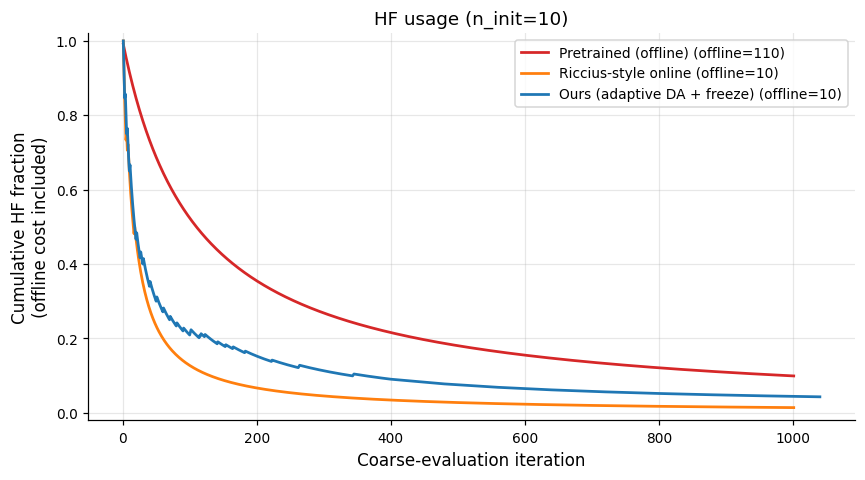

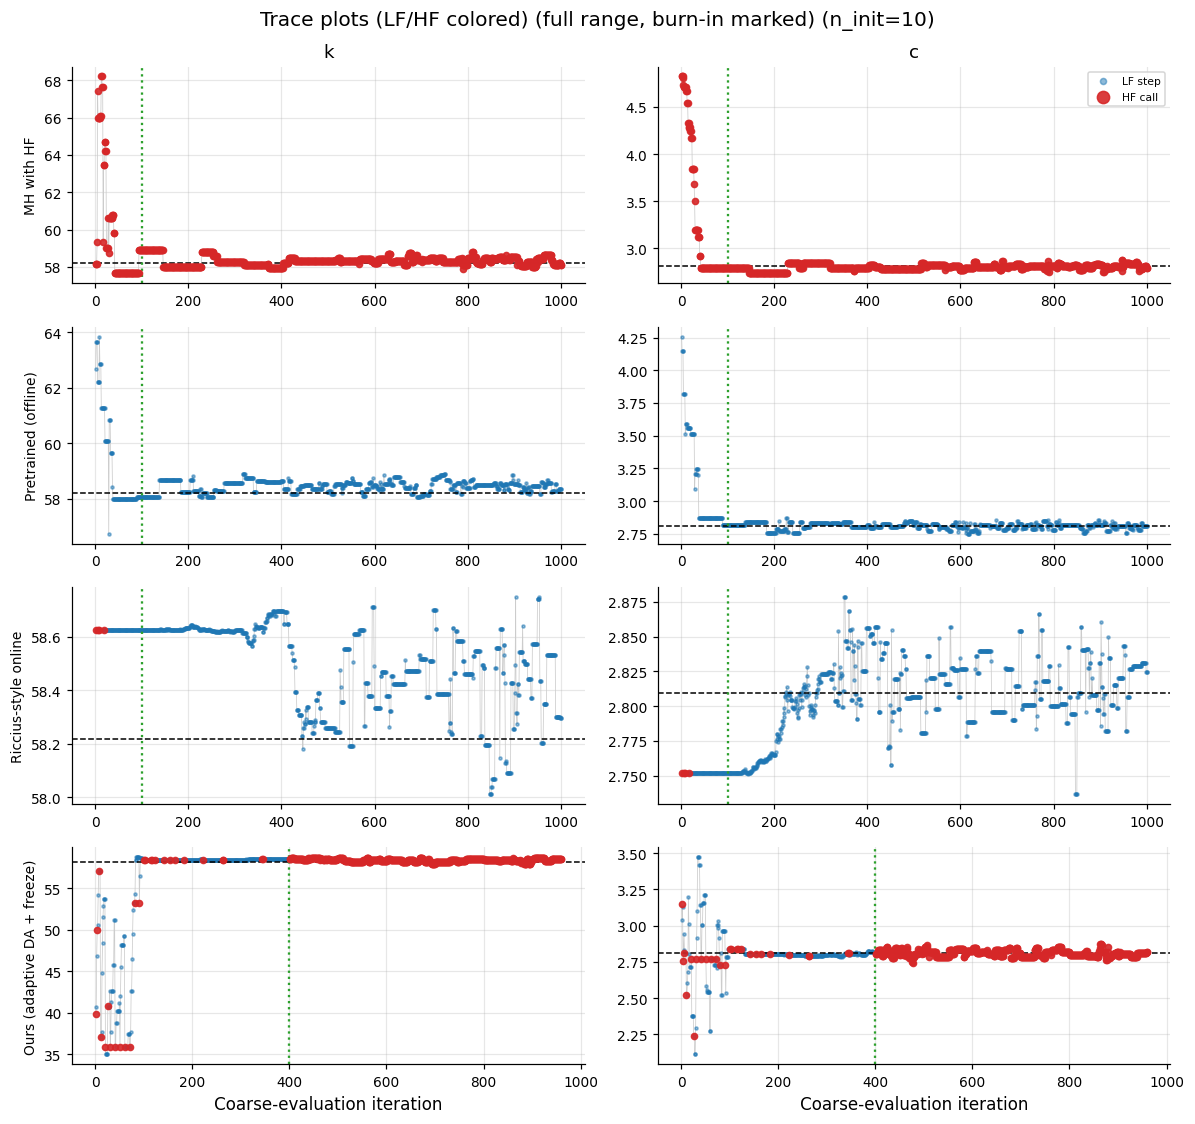

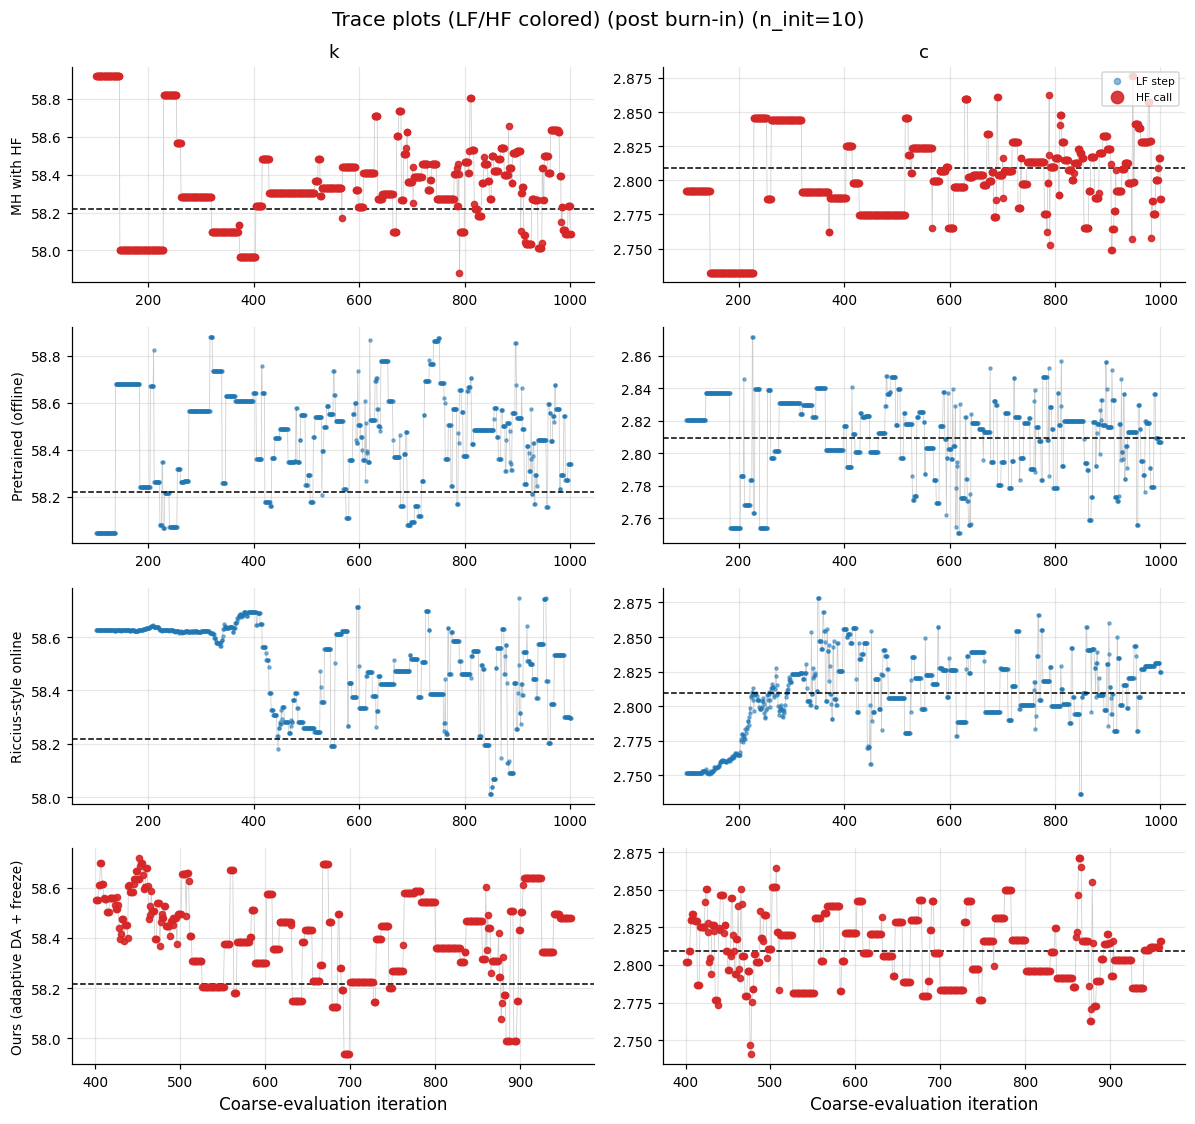

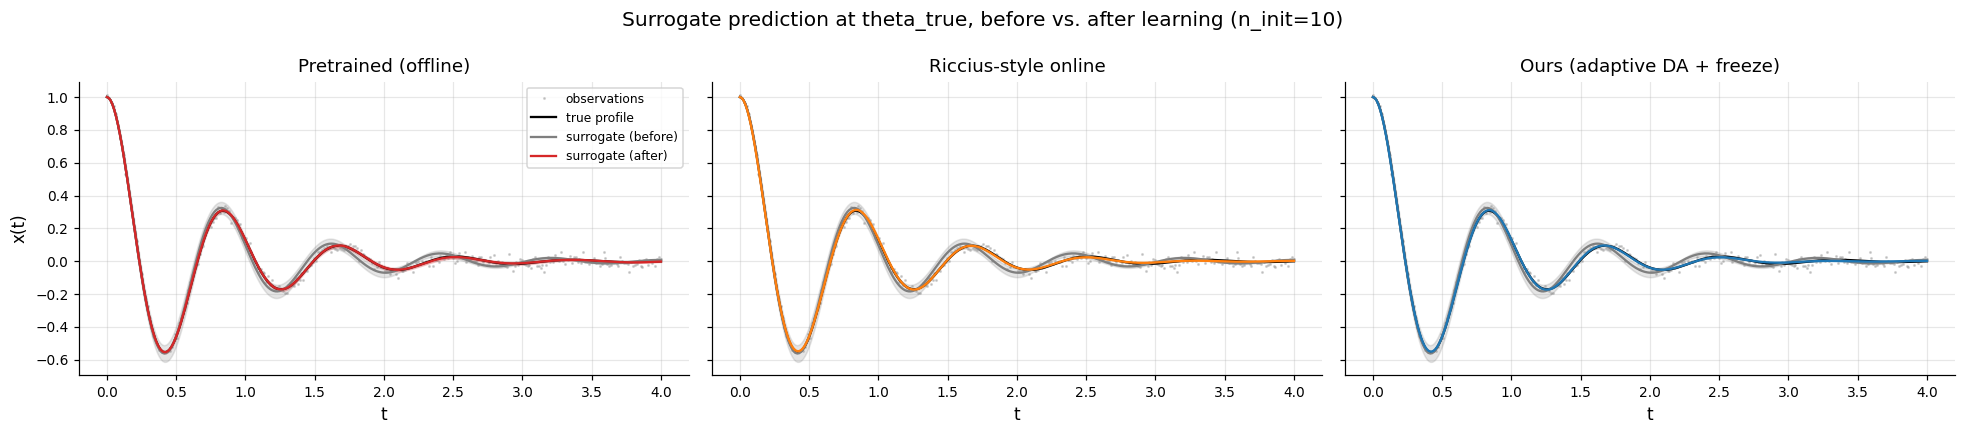

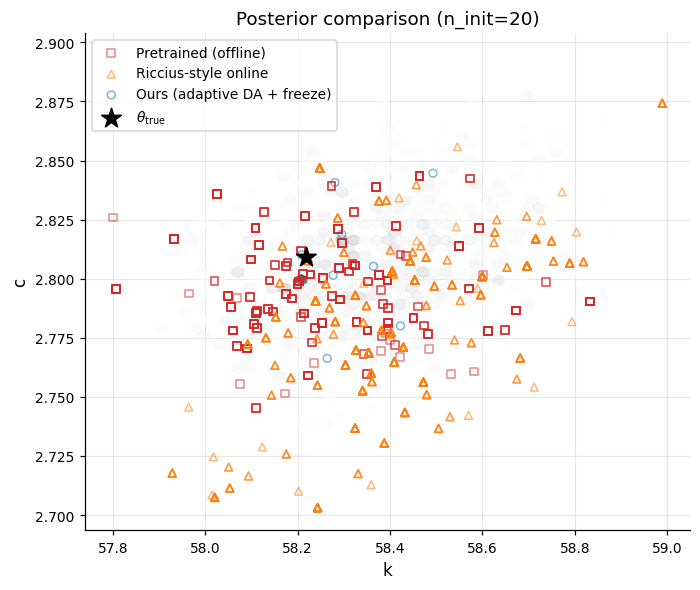

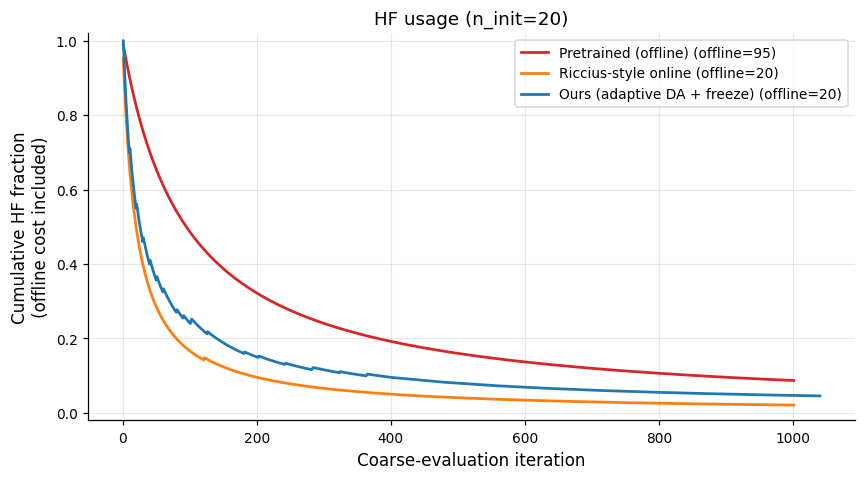

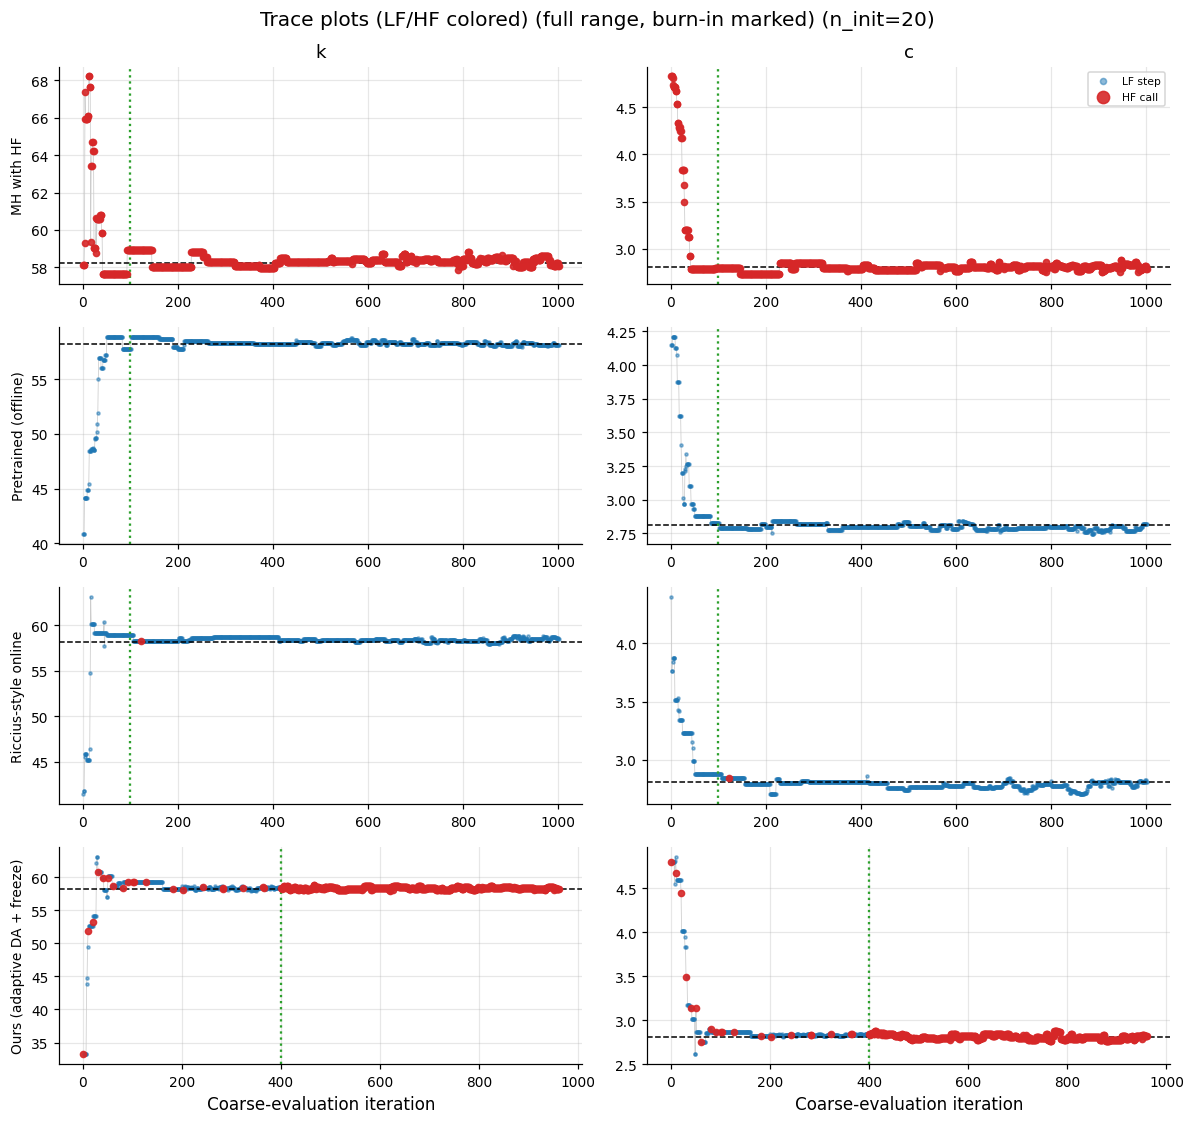

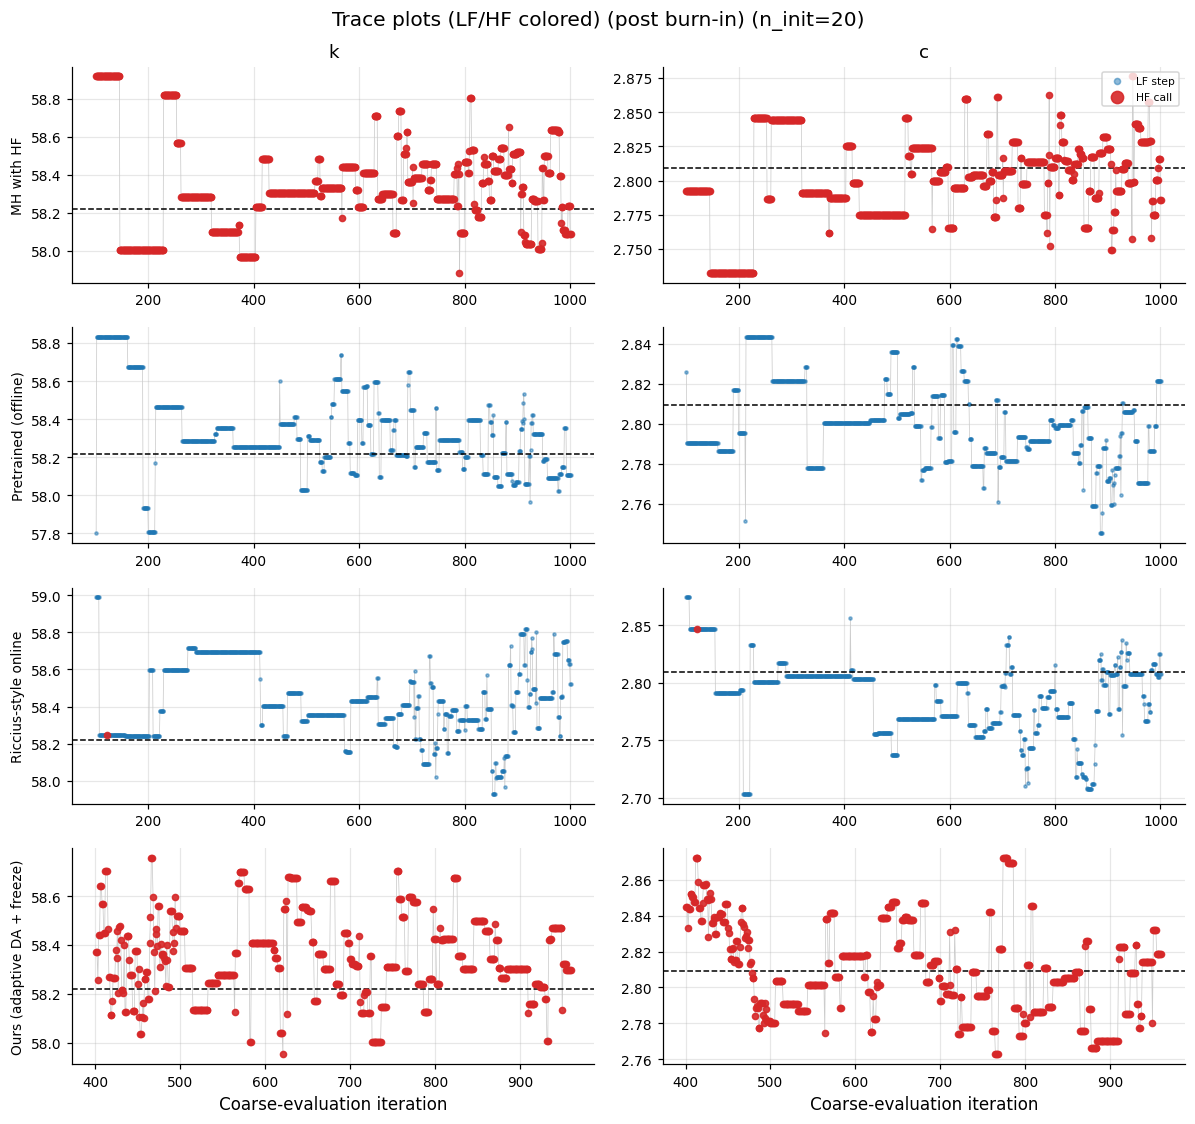

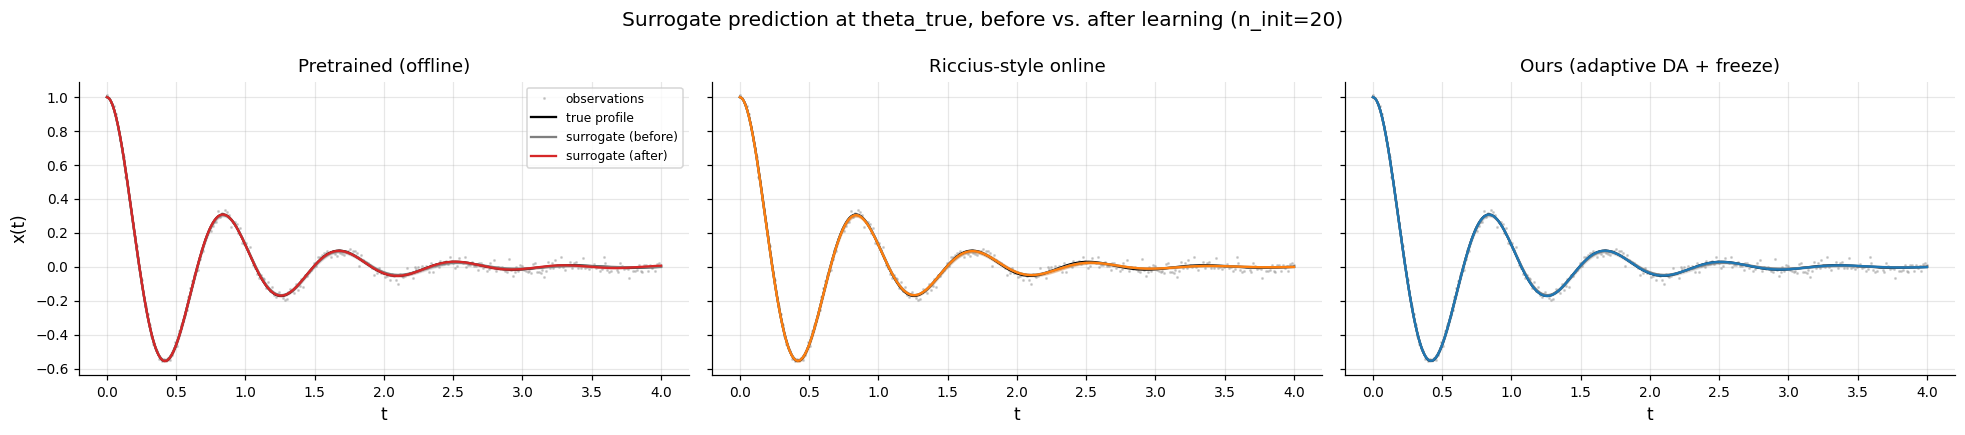

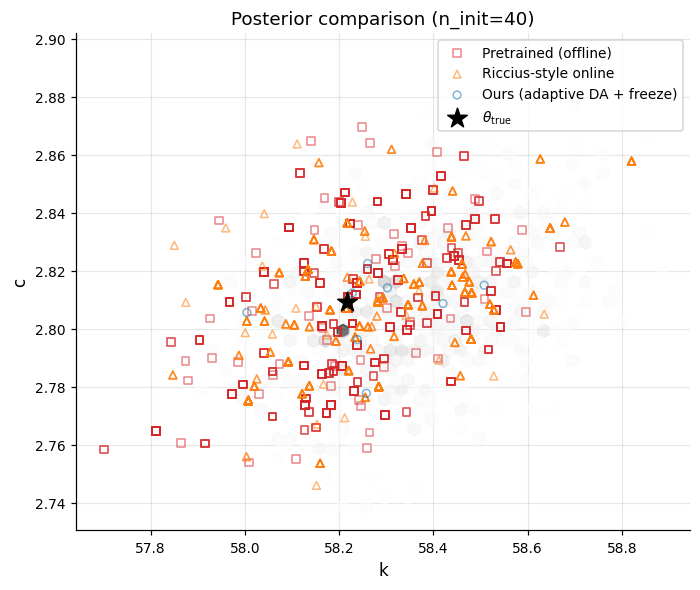

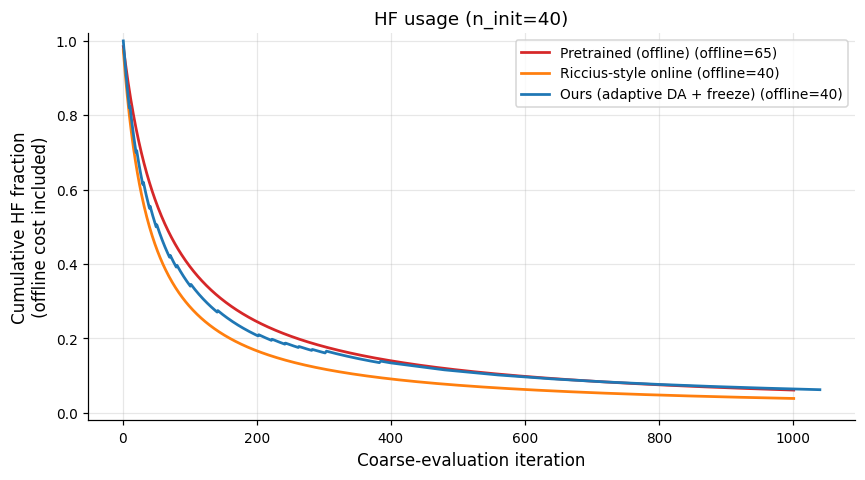

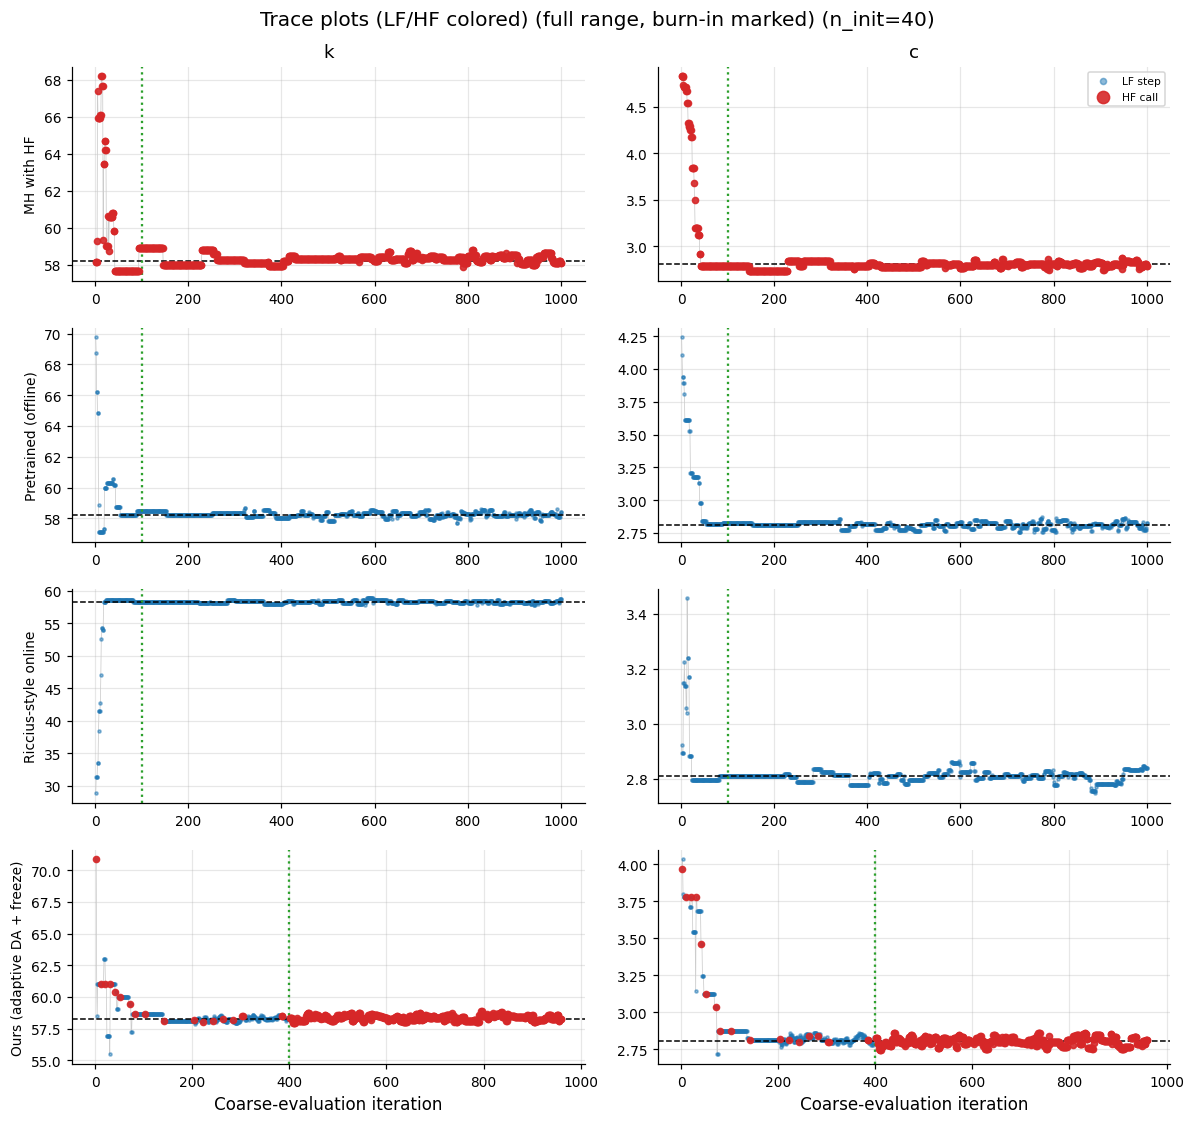

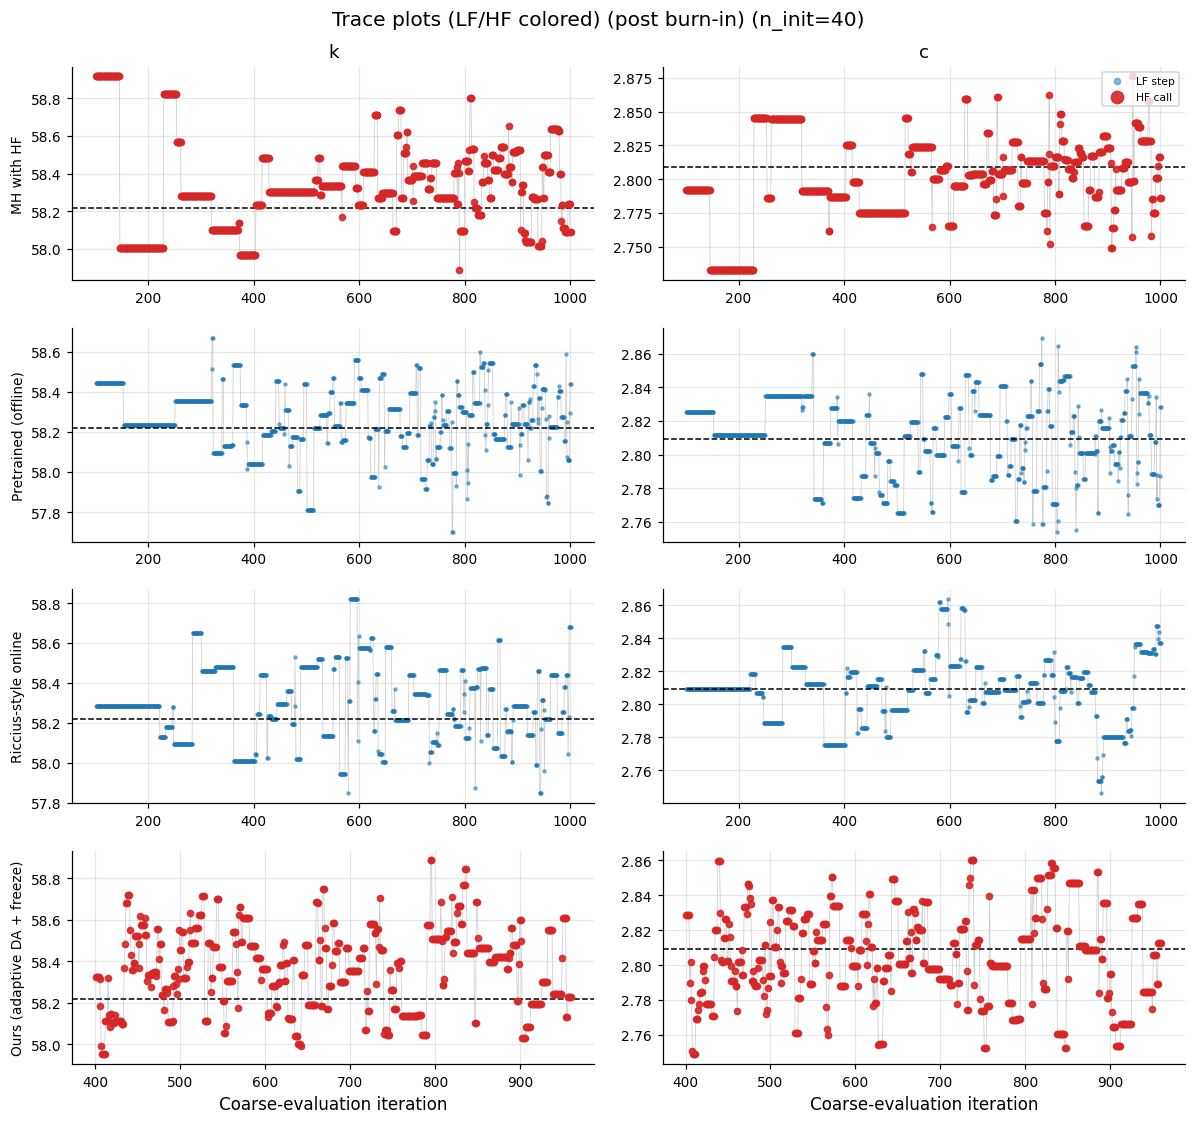

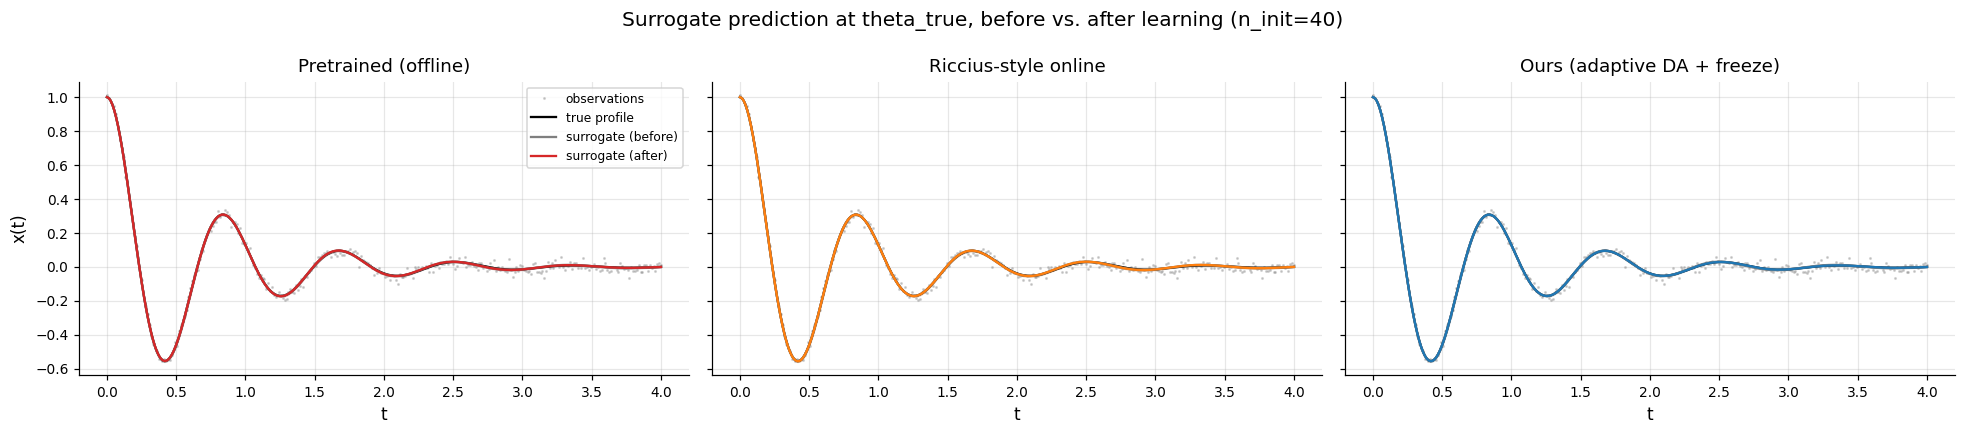

In [5]:
all_results = {}

for n_init in N_INIT_SETTINGS:
    print(f"\n{'=' * 20} n_init = {n_init} {'=' * 20}")

    res = run_all_methods(problem, n_init=n_init, pod_rank=POD_RANK, seed_offset=n_init)
    all_results[n_init] = res

    print(f"\n--- summary (n_init={n_init}) ---")
    print_summary_table(problem, n_init, res)

    trace_chains = {**res["chains"], "hf_only_matched": chain_hf_matched}
    burn_ins = {
        "hf_only_matched": BURN_IN,
        "pretrained": BURN_IN,
        "online_active": BURN_IN,
        "ours": effective_burn_in("ours", meta_ours=res["meta_ours"]),
    }

    fig1 = plot_posterior_comparison(problem, n_init, chain_ref, res["chains"], res["meta_ours"])
    fig2 = plot_hf_fraction(n_init, res["chains"], res["n_hf_pretrained"], res["meta_ours"])
    fig3 = make_hf_colored_trace_fig(
        problem, n_init, trace_chains, res["meta_ours"], burn_ins, "full", " (full range, burn-in marked)"
    )
    fig4 = make_hf_colored_trace_fig(
        problem, n_init, trace_chains, res["meta_ours"], burn_ins, "post_burn_in", " (post burn-in)"
    )
    fig5 = plot_surrogate_before_after(problem, n_init, res["seed_surrogate"], res["surrogates_after"])

    save_fig(fig1, "posterior_comparison", n_init)
    save_fig(fig2, "hf_fraction", n_init)
    save_fig(fig3, "trace_full", n_init)
    save_fig(fig4, "trace_post_burn_in", n_init)
    save_fig(fig5, "surrogate_before_after", n_init)


## 5. Multi-chain convergence check (R-hat / ESS) for each `n_init`

Deferred to its own section since it's the slow part (`N_CHAINS` replicate chains x 4
methods x each `n_init`, and the pretrained baseline's offline active-learning loop is
already the long pole per chain). Reuses the offline design (`seed_X`/`seed_Y`/
`seed_surrogate`) already built for each `n_init` above rather than rebuilding it.

Also produces the *validated* posterior comparison: burn-in found via a Gelman-Rubin
R-hat sweep for every method (not just a heuristic), with samples pooled across all
`N_CHAINS` replicates -- this supersedes section 4's quick-look posterior plot, which
used a single chain and a heuristic burn-in for speed.


In [6]:
# all_convergence = {}

# for n_init in N_INIT_SETTINGS:
#     res = all_results[n_init]
#     print(f"\n--- convergence check (n_init={n_init}, {N_CHAINS} chains) ---")
#     conv, chains_by_method, surrogates_by_method, ours_metas = run_convergence_check(
#         problem,
#         n_init=n_init,
#         pod_rank=POD_RANK,
#         seed_X=res["seed_X"],
#         seed_Y=res["seed_Y"],
#         seed_surrogate=res["seed_surrogate"],
#         n_chains=N_CHAINS,
#         n_coarse_evals=N_COARSE_EVALS_LONG,
#     )
#     all_convergence[n_init] = conv
#     print_convergence_table(conv)

#     fig6 = plot_pooled_posterior_comparison(problem, n_init, chain_ref, conv, chains_by_method)

#     # Multi-chain (all N_CHAINS replicates) versions of section 4's other plot types.
#     offline_costs_by_method = {name: r["pooled"]["n_offline_hf"] for name, r in conv.items()}
#     traces5 = prepare_multichain_traces_section5(chains_by_method, ours_metas)
#     fig8 = plot_hf_fraction_multichain(n_init, traces5, offline_costs_by_method, " (fixed budget)")
#     fig9 = make_hf_colored_trace_fig_multichain(problem, n_init, traces5, " (fixed budget)")
#     fig10 = plot_surrogate_before_after_multichain(
#         problem, n_init, res["seed_surrogate"], surrogates_by_method, " (fixed budget)"
#     )

#     save_fig(fig6, "pooled_posterior_fixed_budget", n_init)
#     save_fig(fig8, "hf_fraction_multichain_fixed_budget", n_init)
#     save_fig(fig9, "trace_multichain_fixed_budget", n_init)
#     save_fig(fig10, "surrogate_multichain_fixed_budget", n_init)

# (RESULTS_DIR / "notebook_convergence_all_n_init.json").write_text(
#     json.dumps(all_convergence, indent=2)
# )


## 5b. Convergence-driven comparison: cost to reach R-hat<=1.01

Section 5 answers "given the same `N_COARSE_EVALS_LONG` budget, how accurate is each
method" -- but that budget isn't the resource the paper is actually claiming to save
(HF calls are), and it silently gives `ours` far fewer posterior draws than the other
methods for the same nominal budget (each of its production rows is a whole DA block,
not one coarse evaluation).

This section instead runs each method **until its `N_CHAINS` replicate chains agree**
(R-hat<=1.01, patience-checked, reusing the exact same `find_burn_in_via_rhat` logic
as section 5) **or a safety cap is hit**, and reports the cost -- HF calls, coarse
evals, wall-clock rounds -- to get there, alongside the resulting accuracy. That's the
comparison a reviewer will look for first: it directly compares methods on the
resource each is meant to save, rather than on an arbitrarily shared iteration count.

Implementation notes (see `run_until_rhat_converged`/`run_convergence_driven_comparison`
in `msd_methods.py` for the full detail):

- The `N_CHAINS` replicates are advanced in synchronized rounds, each round's chunk
  run **in parallel** across processes (`joblib`), so this isn't `N_CHAINS` times
  slower than a single chain despite doing more total work than section 5.
- `CONVERGENCE_DRIVEN_CHUNK_SIZE` controls how often R-hat is (re-)checked; smaller
  means finer-grained stopping at the cost of more parallel-dispatch overhead per
  round. `CONVERGENCE_DRIVEN_MAX_TOTAL_COARSE_EVALS` is the safety valve for methods
  that may never converge in the R-hat sense (e.g. `online_active`/`pretrained`, whose
  replicates can each train a different offline design and drift to different,
  individually-stable-but-mutually-disagreeing answers -- R-hat correctly never
  resolves in that case, which is itself a meaningful finding, not a bug).
- This is naturally slower than section 5 (it's solving a different, harder problem --
  "how long does convergence *actually* take" instead of "what does a fixed budget
  buy") -- expect this cell to take a while at the defaults above.


In [ ]:
all_convergence_driven = {}

for n_init in N_INIT_SETTINGS:
    res = all_results[n_init]
    print(f"\n--- convergence-driven comparison (n_init={n_init}, {N_CHAINS} chains, "
          f"chunk_size={CONVERGENCE_DRIVEN_CHUNK_SIZE}, cap={CONVERGENCE_DRIVEN_MAX_TOTAL_COARSE_EVALS}) ---")
    conv_driven, chains_by_method_driven, surrogates_by_method_driven = run_convergence_driven_comparison(
        problem,
        n_init=n_init,
        rhat_threshold=CONVERGENCE_DRIVEN_RHAT_THRESHOLD,
        min_ess=CONVERGENCE_DRIVEN_MIN_ESS,
        pod_rank=POD_RANK,
        seed_X=res["seed_X"],
        seed_Y=res["seed_Y"],
        seed_surrogate=res["seed_surrogate"],
        n_chains=N_CHAINS,
        chunk_size=CONVERGENCE_DRIVEN_CHUNK_SIZE,
        max_total_coarse_evals=CONVERGENCE_DRIVEN_MAX_TOTAL_COARSE_EVALS,
    )
    all_convergence_driven[n_init] = conv_driven
    print_convergence_driven_table(conv_driven)

    fig7 = plot_pooled_posterior_comparison(problem, n_init, chain_ref, conv_driven, chains_by_method_driven)

    # Multi-chain (all N_CHAINS replicates) versions of section 4's other plot types.
    offline_costs_by_method_driven = {name: r["pooled"]["n_offline_hf"] for name, r in conv_driven.items()}
    traces5b = prepare_multichain_traces_section5b(chains_by_method_driven, conv_driven)
    fig11 = plot_hf_fraction_multichain(n_init, traces5b, offline_costs_by_method_driven, " (convergence-driven)")
    fig12 = make_hf_colored_trace_fig_multichain(problem, n_init, traces5b, " (convergence-driven)")
    fig13 = plot_surrogate_before_after_multichain(
        problem, n_init, res["seed_surrogate"], surrogates_by_method_driven, " (convergence-driven)"
    )

    save_fig(fig7, "pooled_posterior_convergence_driven", n_init)
    save_fig(fig11, "hf_fraction_multichain_convergence_driven", n_init)
    save_fig(fig12, "trace_multichain_convergence_driven", n_init)
    save_fig(fig13, "surrogate_multichain_convergence_driven", n_init)

(RESULTS_DIR / "notebook_convergence_driven_all_n_init.json").write_text(
    json.dumps(all_convergence_driven, indent=2)
)


## 6. Full multi-seed sweep results (if available)

The per-n_init runs above are each a single seed; the actual accuracy/robustness
claims should be based on the multi-seed x n_init sweep, produced by
`run_sweep_msd.py` (slow -- run separately, e.g. in the background:
`python run_sweep_msd.py --n-seeds 10`). This cell loads and summarizes it if it has
already been run.

In [8]:
import pandas as pd

sweep_path = RESULTS_DIR / "sweep_results.csv"
if sweep_path.exists():
    df = pd.read_csv(sweep_path)
    agg = df[df["method"] != "hf_only_reference"].groupby(["n_init", "method"])[
        ["n_hf_calls", "hf_call_fraction", "rmse_to_truth"]
    ].agg(["mean", "median", "std"])
    print(agg)
else:
    print(
        f"{sweep_path} not found yet -- run `python run_sweep_msd.py --n-seeds 10` "
        "(in the background; it takes a while) to generate the full sweep, then "
        "re-run this cell."
    )


/Users/filippozacchei/COde/MFDA_ActiveLearning/examples/toy_problem/results/sweep_results.csv not found yet -- run `python run_sweep_msd.py --n-seeds 10` (in the background; it takes a while) to generate the full sweep, then re-run this cell.
